# Burn severity assessment of the Veluwe fire in April 2026

## Settings

### Packages

In [ ]:
## List packages
pkgs <- c("rstac", "sf", "lubridate", "dplyr", "terra", "tidyterra")

## Install missing packages
pkgs_installed <- pkgs %in% rownames(installed.packages())
#if (any(pkgs_installed == FALSE)) install.packages(pkgs[!pkgs_installed])
if (any(pkgs_installed == FALSE)) print(pkgs[!pkgs_installed])

## Load packages
invisible(lapply(pkgs, library, character.only = TRUE))

### Plotting options

In [ ]:
options(repr.plot.width  =  12,
        repr.plot.height =   8,
        repr.plot.res    = 150)

### Custom functions

In [ ]:
## Convert dates to RFC3339 format
date2rfc3339 <- function(x) format(as_datetime(x), "%Y-%m-%dT%H:%M:%SZ")

## Select and download STAC assets
stac_download <- function(endpoint, collection, limit = 100,
                          start_date, end_date, target_date = NULL,
                          bbox = NULL, roi_path = NULL, thresh_cloud = NULL,
                          asset_names = NULL, out_path = tempdir()) {

    ### Load packages
    library(sf)
    library(rstac)

    ### Format date range
    daterange <- paste(lapply(c(start_date, end_date), FUN = date2rfc3339), collapse = "/")

    ### Perform initial dataset search query
    search <- stac(endpoint) |>
      stac_search(collections = collection,
                  datetime    = daterange,
                  limit       = limit)
    
    if(!is.null(bbox)) { search <- stac_search(search, bbox = bbox) }
    if(!is.null(roi_path)) { search <- stac_search(search, intersects = st_read(roi_path, quiet = TRUE)) }

    ### (Sub)select and fetch items
    items <- post_request(search)
    if(!is.null(thresh_cloud)) {
        items <- post_request(search)
        suppressWarnings(items <- items_filter(items, properties$`eo:cloud_cover` < thresh_cloud))
    }
    items <- items_fetch(items, progress = FALSE)
    if(!is.null(asset_names)) {
        items <- assets_select(items, asset_names = asset_names)
    }
    if(!is.null(target_date)) {
        target_date <- date2rfc3339(target_date)
        items <- items_select(items, selection = which(items_datetime(items) == as.Date(target_date)))
    }

    ### Download assets
    assets_json <- assets_download(items       = items,
                                   asset_names = asset_names,
                                   output_dir  = out_path,
                                   overwrite   = TRUE,
                                   use_gdal    = FALSE,
                                   progress    = FALSE)
}

### Parameters

In [ ]:
## STAC endpoint URL
cons_endpoint <- "https://planetarycomputer.microsoft.com/api/stac/v1"

## Dataset collection ID
param_collection <- "sentinel-2-l2a"

## Path to the file defining the region-of-interest
param_roi_path <- paste0(getwd(), "/data/rois/wf_veluwe_2026.gpkg")

## Target coordinate reference system code
param_crs_t <- "EPSG:32631"

## Start and end dates of the wildfire event
param_date_start <- "2026-04-29"
param_date_end <- "2026-04-30"

## Pre- and post-fire dates
param_date_pre <- "2026-04-22"
param_date_post <- "2026-05-07"

## Cloud cover threshold
param_thresh_cloud <- 30

## Asset codes
param_bands <- c("B02", "B03", "B04", "B8A", "B12")

## Path to the directory to save outputs
param_dir_out <- tempdir()
if (!dir.exists(param_dir_out)) dir.create(param_dir_out)

## Region of interest

### Import and reproject boundaries

In [ ]:
## Netherlands
nl <- "data/rois/nl.gpkg" |>
  st_read(quiet = TRUE) |>
  st_as_sf() |>
  st_transform(crs = st_crs(4326))

## Veluwe
veluwe <- "data/rois/veluwe.gpkg" |>
  st_read(quiet = TRUE) |>
  st_as_sf() |>
  st_transform(crs = st_crs(4326))

## Burned area
roi <- param_roi_path |>
  st_read(quiet = TRUE) |>
  st_as_sf() |>
  st_transform(crs = st_crs(4326))
roi_sv <- roi |>
  vect() |>
  project(param_crs_t)

### Visualize region of interest

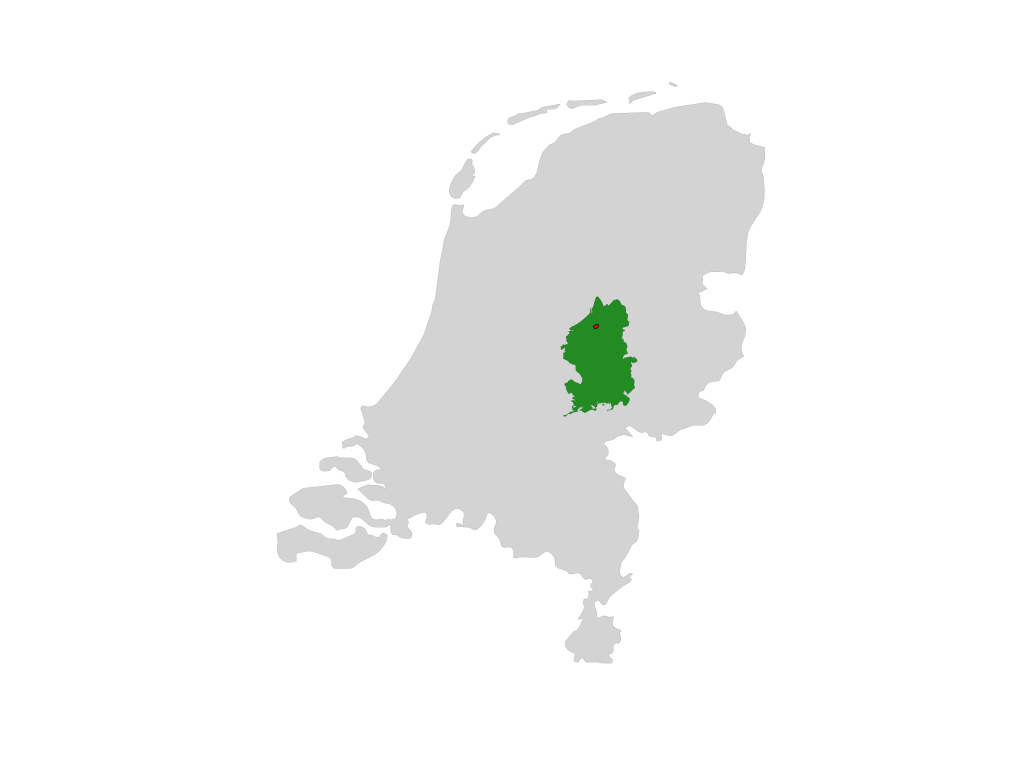

In [32]:
plot(nl$geom, col = "lightgray", lwd = 0.1)
plot(veluwe$geom, col = "forestgreen", lwd = 0.1, add = TRUE)
plot(roi$geom, col = "red", lwd = 1, add = TRUE)

## Data downloading

### Query and fetch items

In [33]:
items <- stac(cons_endpoint) |>
  stac_search(collections = param_collection,
              datetime    = paste(lapply(c(param_date_pre, param_date_post),
                                         FUN = date2rfc3339), collapse = "/"),
              limit       = 100,
              intersects  = roi) |>
  post_request() |>
  items_sign_planetary_computer() |>
  items_filter(properties$`eo:cloud_cover` < 10) |>
  assets_select(asset_names = param_bands)
print(items)

###Items
- features (5 item(s)):
  - S2A_MSIL2A_20260501T104651_R051_T31UFU_20260501T173800
  - S2B_MSIL2A_20260501T103619_R008_T31UFU_20260501T143617
  - S2C_MSIL2A_20260429T105031_R051_T31UFU_20260429T144516
  - S2A_MSIL2A_20260428T104041_R008_T31UFU_20260428T173009
  - S2C_MSIL2A_20260426T104021_R008_T31UFU_20260426T160712
- assets: B02, B03, B04, B12, B8A
- item's fields: 
assets, bbox, collection, geometry, id, links, properties, stac_extensions, stac_version, type


### Download assets

In [ ]:
assets_json <- assets_download(items       = items,
                               asset_names = param_bands,
                               output_dir  = param_dir_out,
                               overwrite   = TRUE,
                               use_gdal    = FALSE,
                               progress    = FALSE)
items_as_tibble(assets_json)

# A tibble: 5 × 32
  constellation datetime       `eo:cloud_cover` instruments platform `proj:epsg` s2:cloud_shadow_perc…¹
  <chr>         <chr>                     <dbl> <chr>       <chr>          <int>                  <dbl>
1 Sentinel 2    2026-05-01T10…           0.0237 msi         Sentine…       32631                0.00236
2 Sentinel 2    2026-05-01T10…           0.0699 msi         Sentine…       32631                0.0195 
3 Sentinel 2    2026-04-29T10…           9.72   msi         Sentine…       32631                0.0657 
4 Sentinel 2    2026-04-28T10…           2.58   msi         Sentine…       32631                0.0250 
5 Sentinel 2    2026-04-26T10…           6.79   msi         Sentine…       32631                0.585  
# ℹ abbreviated name: ¹​`s2:cloud_shadow_percentage`
# ℹ 25 more variables: `s2:datastrip_id` <chr>, `s2:datatake_id` <chr>, `s2:datatake_type` <chr>,
#   `s2:degraded_msi_data_percentage` <dbl>, `s2:generation_time` <chr>, `s2:granule_id` <chr>,
#   `s

### List downloaded files

In [ ]:
dl_files <- list.files(path = param_dir_out, pattern = "*.tif",
                       full.names = TRUE, recursive = TRUE)
print(dl_files)

 [1] "/tmp/RtmpIl4Fj9/sentinel2-l2/31/U/FU/2026/04/26/S2C_MSIL2A_20260426T104021_N0512_R008_T31UFU_20260426T160712.SAFE/GRANULE/L2A_T31UFU_A008558_20260426T104343/IMG_DATA/R10m/T31UFU_20260426T104021_B02_10m.tif"
 [2] "/tmp/RtmpIl4Fj9/sentinel2-l2/31/U/FU/2026/04/26/S2C_MSIL2A_20260426T104021_N0512_R008_T31UFU_20260426T160712.SAFE/GRANULE/L2A_T31UFU_A008558_20260426T104343/IMG_DATA/R10m/T31UFU_20260426T104021_B03_10m.tif"
 [3] "/tmp/RtmpIl4Fj9/sentinel2-l2/31/U/FU/2026/04/26/S2C_MSIL2A_20260426T104021_N0512_R008_T31UFU_20260426T160712.SAFE/GRANULE/L2A_T31UFU_A008558_20260426T104343/IMG_DATA/R10m/T31UFU_20260426T104021_B04_10m.tif"
 [4] "/tmp/RtmpIl4Fj9/sentinel2-l2/31/U/FU/2026/04/26/S2C_MSIL2A_20260426T104021_N0512_R008_T31UFU_20260426T160712.SAFE/GRANULE/L2A_T31UFU_A008558_20260426T104343/IMG_DATA/R20m/T31UFU_20260426T104021_B12_20m.tif"
 [5] "/tmp/RtmpIl4Fj9/sentinel2-l2/31/U/FU/2026/04/26/S2C_MSIL2A_20260426T104021_N0512_R008_T31UFU_20260426T160712.SAFE/GRANULE/L2A_T31UFU_A008558_2

### Build properties table

In [ ]:
dl_files_sep <- strsplit(dl_files, split = "/")
dl_files_df <- cbind(dl_files, as.data.frame(do.call(rbind, lapply(dl_files_sep, rbind))))
names(dl_files_df) <- c("path", "root", "dir", "subdir", "collection", "zone",
                        "area", "tile", "year", "month", "day", "band", "type",
                        "granule", "content", "resolution", "filename")
dl_files_df

                                                                                                                                                                                                            path
1  /tmp/RtmpIl4Fj9/sentinel2-l2/31/U/FU/2026/04/26/S2C_MSIL2A_20260426T104021_N0512_R008_T31UFU_20260426T160712.SAFE/GRANULE/L2A_T31UFU_A008558_20260426T104343/IMG_DATA/R10m/T31UFU_20260426T104021_B02_10m.tif
2  /tmp/RtmpIl4Fj9/sentinel2-l2/31/U/FU/2026/04/26/S2C_MSIL2A_20260426T104021_N0512_R008_T31UFU_20260426T160712.SAFE/GRANULE/L2A_T31UFU_A008558_20260426T104343/IMG_DATA/R10m/T31UFU_20260426T104021_B03_10m.tif
3  /tmp/RtmpIl4Fj9/sentinel2-l2/31/U/FU/2026/04/26/S2C_MSIL2A_20260426T104021_N0512_R008_T31UFU_20260426T160712.SAFE/GRANULE/L2A_T31UFU_A008558_20260426T104343/IMG_DATA/R10m/T31UFU_20260426T104021_B04_10m.tif
4  /tmp/RtmpIl4Fj9/sentinel2-l2/31/U/FU/2026/04/26/S2C_MSIL2A_20260426T104021_N0512_R008_T31UFU_20260426T160712.SAFE/GRANULE/L2A_T31UFU_A008558_20260426T104343/IMG_

### Select and import during-fire images

In [ ]:
during_list <- dl_files_df |>
  filter(month == "04",
         day %in% c("29", "30"),
         resolution == "R10m")

s2_during <- rast(during_list$path)
names(s2_during) <- c("Blue", "Green", "Red")
print(s2_during)

class       : SpatRaster 
dimensions  : 10980, 10980, 3  (nrow, ncol, nlyr)
resolution  : 10, 10  (x, y)
extent      : 6e+05, 709800, 5790240, 5900040  (xmin, xmax, ymin, ymax)
coord. ref. : WGS 84 / UTM zone 31N (EPSG:32631) 
sources     : T31UFU_20260429T105031_B02_10m.tif  
              T31UFU_20260429T105031_B03_10m.tif  
              T31UFU_20260429T105031_B04_10m.tif  
names       : Blue, Green, Red 


### Visualize during-fire image

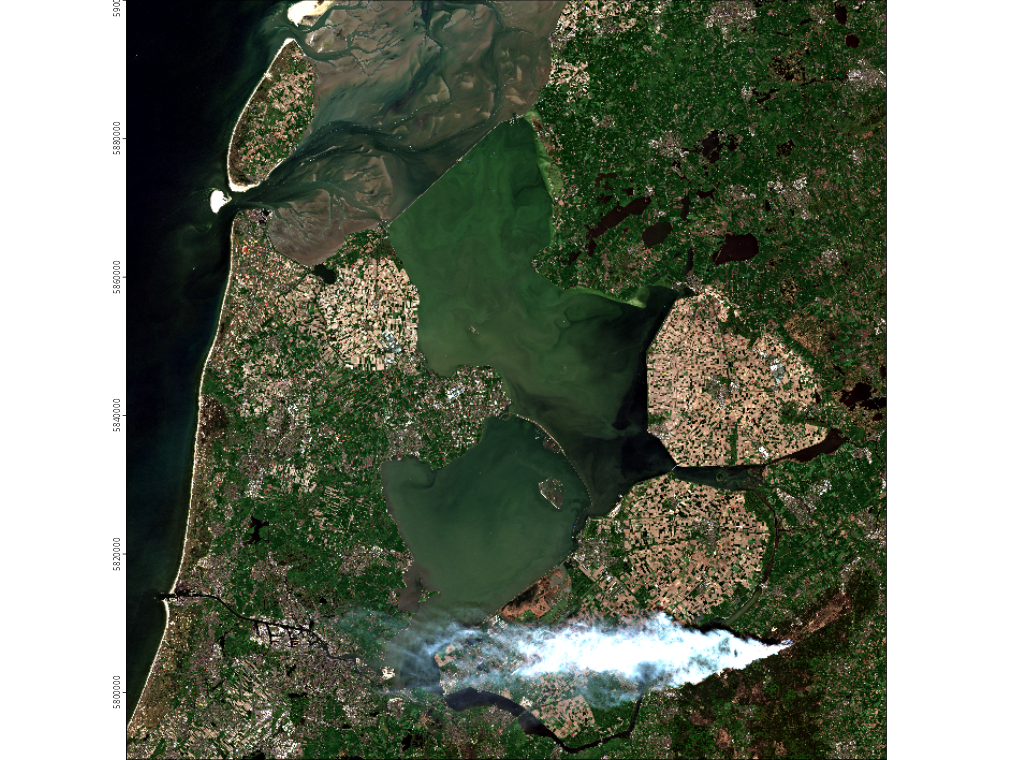

In [50]:
plotRGB(s2_during,
        r = 3, g = 2, b = 1,
        stretch = "lin",
        axes = TRUE,
        legend = FALSE,
        main = "Veluwe fire (29-30 April 2026)")

### Select and import pre-fire images

In [54]:
pre_list <- dl_files_df |>
  filter(month == "04",
         day < "29",
         resolution == "R20m")
s2_pre <- rast(pre_list$path)
print(s2_pre)

class       : SpatRaster 
dimensions  : 5490, 5490, 4  (nrow, ncol, nlyr)
resolution  : 20, 20  (x, y)
extent      : 6e+05, 709800, 5790240, 5900040  (xmin, xmax, ymin, ymax)
coord. ref. : WGS 84 / UTM zone 31N (EPSG:32631) 
sources     : T31UFU_20260426T104021_B12_20m.tif  
              T31UFU_20260426T104021_B8A_20m.tif  
              T31UFU_20260428T104041_B12_20m.tif  
              T31UFU_20260428T104041_B8A_20m.tif  
names       : T31UFU_~B12_20m, T31UFU_~B8A_20m, T31UFU_~B12_20m, T31UFU_~B8A_20m 


### Select and import post-fire images

In [55]:
post_list <- dl_files_df |>
  filter(month == "05",
         day >= "01",
         resolution == "R20m")
s2_post <- rast(post_list$path)
print(s2_post)

class       : SpatRaster 
dimensions  : 5490, 5490, 4  (nrow, ncol, nlyr)
resolution  : 20, 20  (x, y)
extent      : 6e+05, 709800, 5790240, 5900040  (xmin, xmax, ymin, ymax)
coord. ref. : WGS 84 / UTM zone 31N (EPSG:32631) 
sources     : T31UFU_20260501T104651_B12_20m.tif  
              T31UFU_20260501T104651_B8A_20m.tif  
              T31UFU_20260501T103619_B12_20m.tif  
              T31UFU_20260501T103619_B8A_20m.tif  
names       : T31UFU_~B12_20m, T31UFU_~B8A_20m, T31UFU_~B12_20m, T31UFU_~B8A_20m 


## Pre-processing

### Crop pre-fire images

class       : SpatRaster 
dimensions  : 131, 161, 4  (nrow, ncol, nlyr)
resolution  : 20, 20  (x, y)
extent      : 693460, 696680, 5805480, 5808100  (xmin, xmax, ymin, ymax)
coord. ref. : WGS 84 / UTM zone 31N (EPSG:32631) 
source      : s2_pre.tif 
names       : pre1_B12, pre1_B8A, pre2_B12, pre2_B8A 
min values  :     1479,     2404,     1458,     2402 
max values  :     5878,     5179,     5946,     5125 


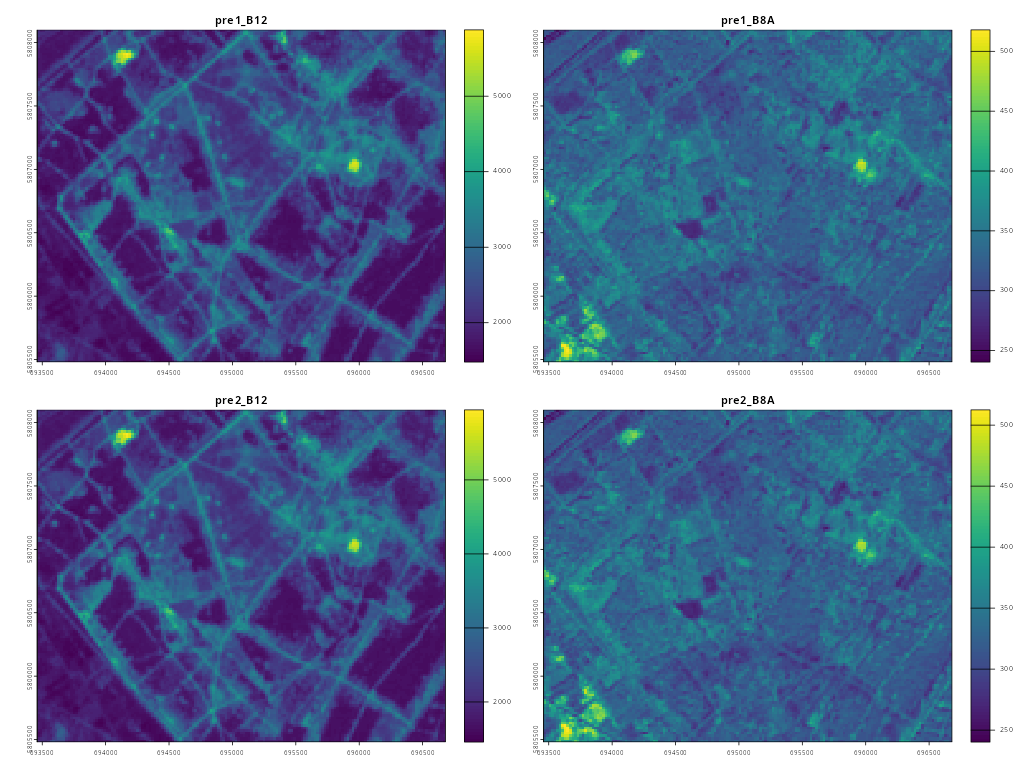

In [152]:
s2_pre_path <- paste0(param_dir_out, "/s2_pre.tif")
crop(x = s2_pre, y = buffer(roi_sv, 200), mask = FALSE,
     filename = s2_pre_path, overwrite = TRUE)
gc()

s2_pre_c <- rast(s2_pre_path)
names(s2_pre_c) <- paste0("pre", c("1_B12", "1_B8A", "2_B12", "2_B8A"))
print(s2_pre_c)
plot(s2_pre_c)

### Crop post-fire images

class       : SpatRaster 
dimensions  : 131, 161, 4  (nrow, ncol, nlyr)
resolution  : 20, 20  (x, y)
extent      : 693460, 696680, 5805480, 5808100  (xmin, xmax, ymin, ymax)
coord. ref. : WGS 84 / UTM zone 31N (EPSG:32631) 
source      : s2_post.tif 
names       : post1_B12, post1_B8A, post2_B12, post2_B8A 
min values  :      1396,      1324,      1472,      1372 
max values  :      5786,      5006,      6118,      5257 


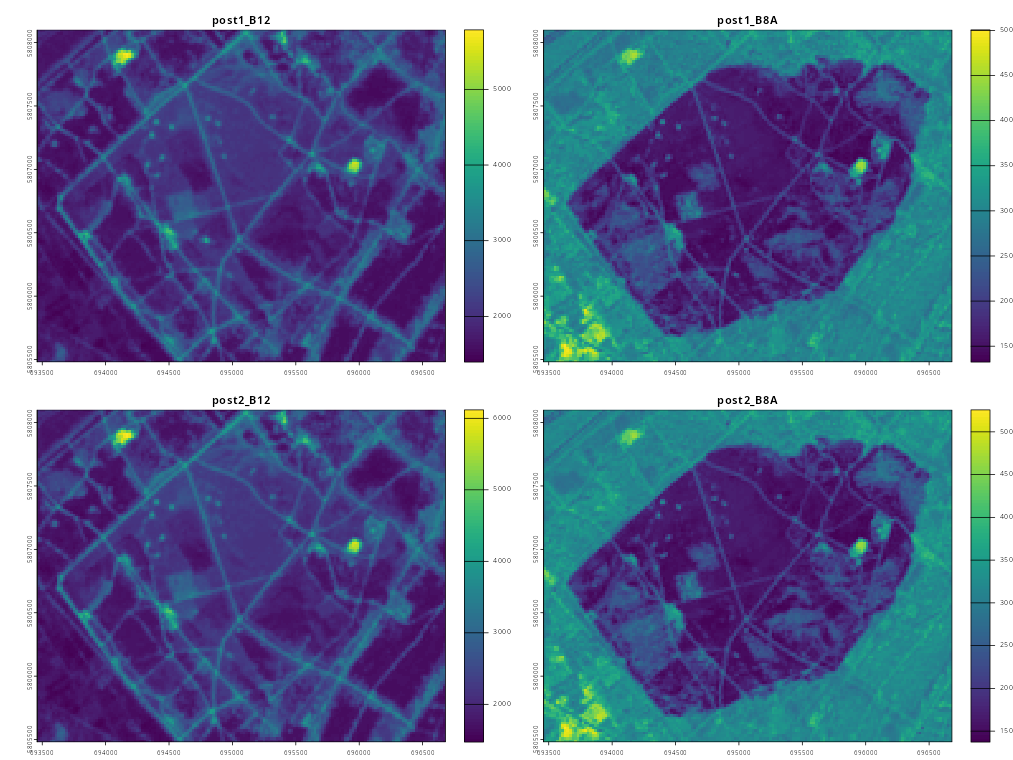

In [157]:
s2_post_path <- paste0(param_dir_out, "/s2_post.tif")
crop(x = s2_post, y = buffer(roi_sv, 200), mask = FALSE,
     filename = s2_post_path, overwrite = TRUE)
gc()

s2_post_c <- rast(s2_post_path)
names(s2_post_c) <- paste0("post", c("1_B12", "1_B8A", "2_B12", "2_B8A"))
print(s2_post_c)
plot(s2_post_c)

### Calculate pre-fire average

In [158]:
s2_pre_avg_path <- paste0(param_dir_out, "/s2_pre_avg.tif")
tapp(x = rast(s2_pre_path),
     index = c(1, 2, 1, 2),
     fun = \(x) mean(x, rm.na = TRUE), cores = 3,
     filename = s2_pre_avg_path, overwrite = TRUE)
gc()

s2_pre_avg <- rast(s2_pre_avg_path)
names(s2_pre_avg) <- paste0("pre_", c("B12", "B8A"))
print(s2_pre_avg)

class       : SpatRaster 
dimensions  : 131, 161, 2  (nrow, ncol, nlyr)
resolution  : 20, 20  (x, y)
extent      : 693460, 696680, 5805480, 5808100  (xmin, xmax, ymin, ymax)
coord. ref. : WGS 84 / UTM zone 31N (EPSG:32631) 
source      : s2_pre_avg.tif 
names       : pre_B12, pre_B8A 
min values  :  1468.5,    2403 
max values  :  5912.0,    5152 


### Calculate post-fire average

In [159]:
s2_post_avg_path <- paste0(param_dir_out, "/s2_post_avg.tif")
tapp(x = rast(s2_post_path),
     index = c(1, 2, 1, 2),
     fun = \(x) mean(x, rm.na = TRUE), cores = 3,
     filename = s2_post_avg_path, overwrite = TRUE)
gc()

s2_post_avg <- rast(s2_post_avg_path)
names(s2_post_avg) <- paste0("post_", c("B12", "B8A"))
print(s2_post_avg)

class       : SpatRaster 
dimensions  : 131, 161, 2  (nrow, ncol, nlyr)
resolution  : 20, 20  (x, y)
extent      : 693460, 696680, 5805480, 5808100  (xmin, xmax, ymin, ymax)
coord. ref. : WGS 84 / UTM zone 31N (EPSG:32631) 
source      : s2_post_avg.tif 
names       : post_B12, post_B8A 
min values  :   1437.5,   1369.0 
max values  :   5932.0,   5097.5 


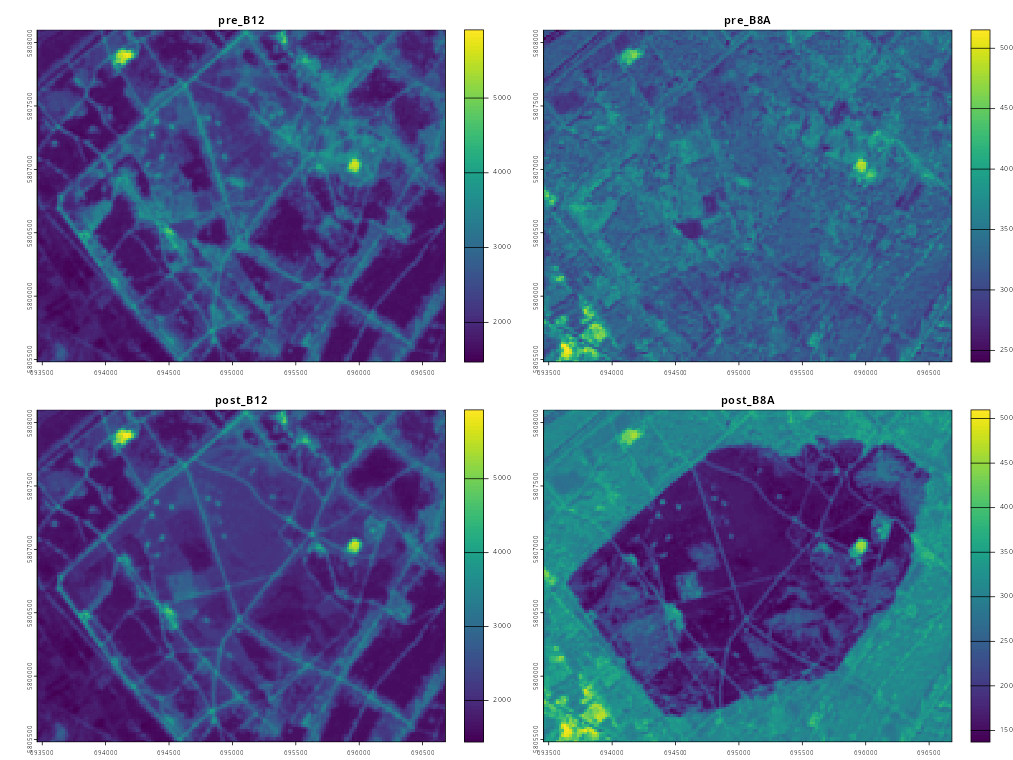

In [160]:
s2_avg_path <- paste0(param_dir_out, "/s2_avg.tif")
writeRaster(c(s2_pre_avg, s2_post_avg),
            filename = s2_avg_path, overwrite = TRUE)

s2_avg <- rast(s2_avg_path)
plot(s2_avg)

## Burn severity assessment

### Compute NBR

The Normalized Burn Ratio (NBR) can be calculated, from the Sentinel-2 bands 8 (near-infrared, NIR) and 12 (shortwave-infrared, SWIR), using the following expression:

$`NBR = {(NIR - SWIR) \over{(NIR + SWIR)}}`$

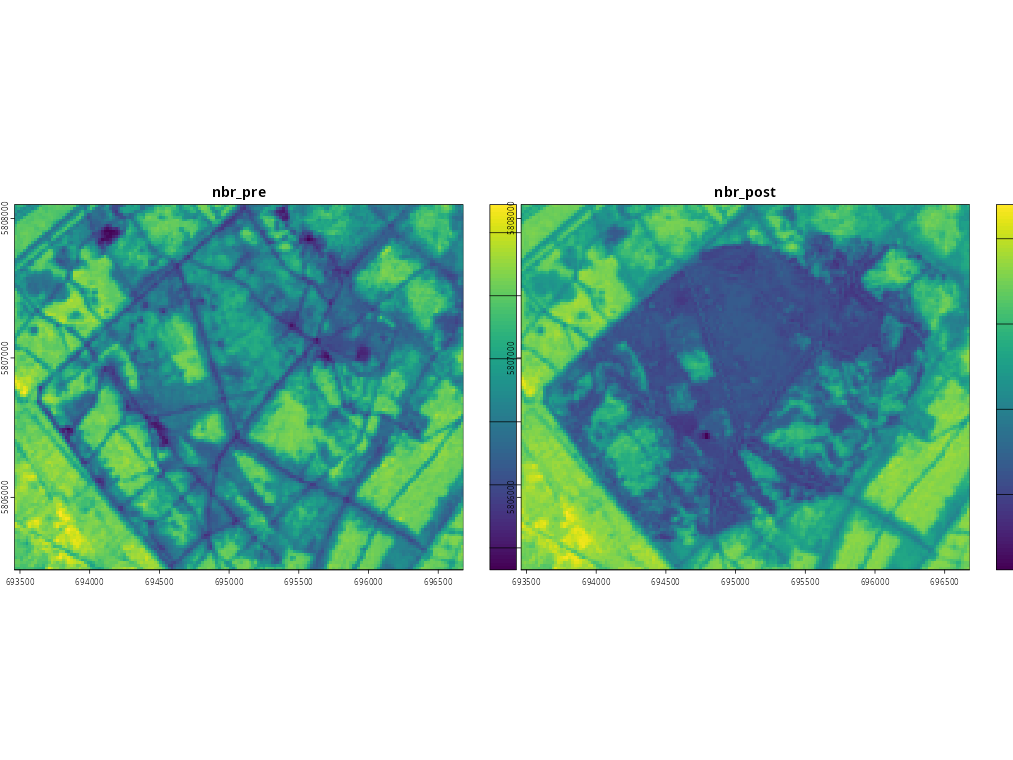

In [161]:
s2_nbr_path <- paste0(param_dir_out, "/s2_nbr.tif")
tapp(x = rast(s2_avg_path),
     index = c(1, 1, 2, 2),
     fun = \(x) (x[[2]] - x[[1]]) / (x[[2]] + x[[1]]), cores = 3,
     filename = s2_nbr_path, overwrite = TRUE)

s2_nbr <- rast(s2_nbr_path)
names(s2_nbr) <- paste0("nbr_", c("pre", "post"))
plot(s2_nbr)

### Calculate dNBR

Burn severity can be mapped using Delta-NBR, calculated as follows:

$`dNBR = {NBR_{pre} - NBR_{post}}`$

In [171]:
s2_dnbr_path <- paste0(param_dir_out, "/s2_dnbr.tif")
app(x = rast(s2_nbr_path),
    fun = \(x) (x[[1]] - x[[2]]), cores = 3,
    filename = s2_dnbr_path, overwrite = TRUE)

class       : SpatRaster 
dimensions  : 131, 161, 1  (nrow, ncol, nlyr)
resolution  : 20, 20  (x, y)
extent      : 693460, 696680, 5805480, 5808100  (xmin, xmax, ymin, ymax)
coord. ref. : WGS 84 / UTM zone 31N (EPSG:32631) 
source      : s2_dnbr.tif 
name        :       lyr.1 
min value   : -0.07949677 
max value   :  0.70653677 

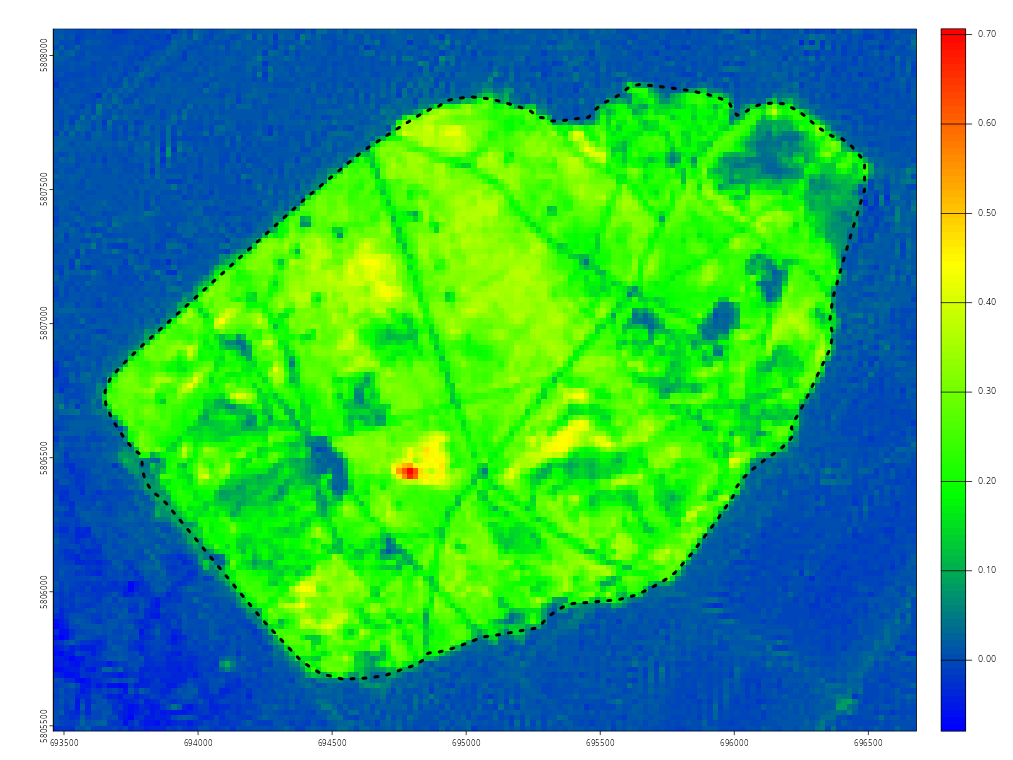

In [176]:
s2_dnbr <- rast(s2_dnbr_path) |>
  crop(buffer(roi_sv, 200), mask = FALSE)
s2_dnbr |>
  clamp(lower = -0.25, upper = 0.75) |>
  plot(col = map.pal("bgyr", n = 100))
plot(roi_sv, lty = 3, lwd = 4, add = TRUE)

### Analyze distribution

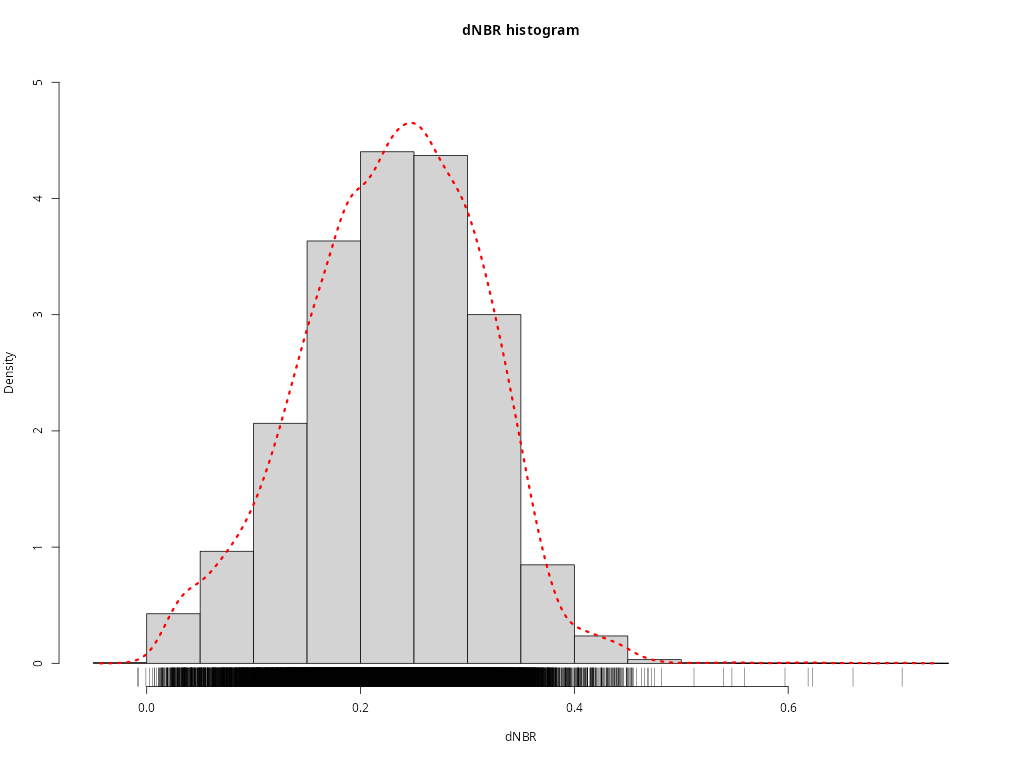

In [181]:
dnbr_vals <- s2_dnbr |>
  crop(roi_sv, mask = TRUE) |>
  values() |>
  na.omit() |>
  as.vector()
write.csv(dnbr_vals, "out/tables/dnbr_veluwe.csv", row.names = FALSE)

hist(dnbr_vals, prob = TRUE,
     ylim = c(0, 5), #xlim = c(-0.2, 1),
     main = "dNBR histogram", xlab = "dNBR")
lines(density(dnbr_vals),
      col = "red", lwd = 3, lty = 3)
rug(jitter(dnbr_vals), lwd = 0.5)

### Compare with Rhodes

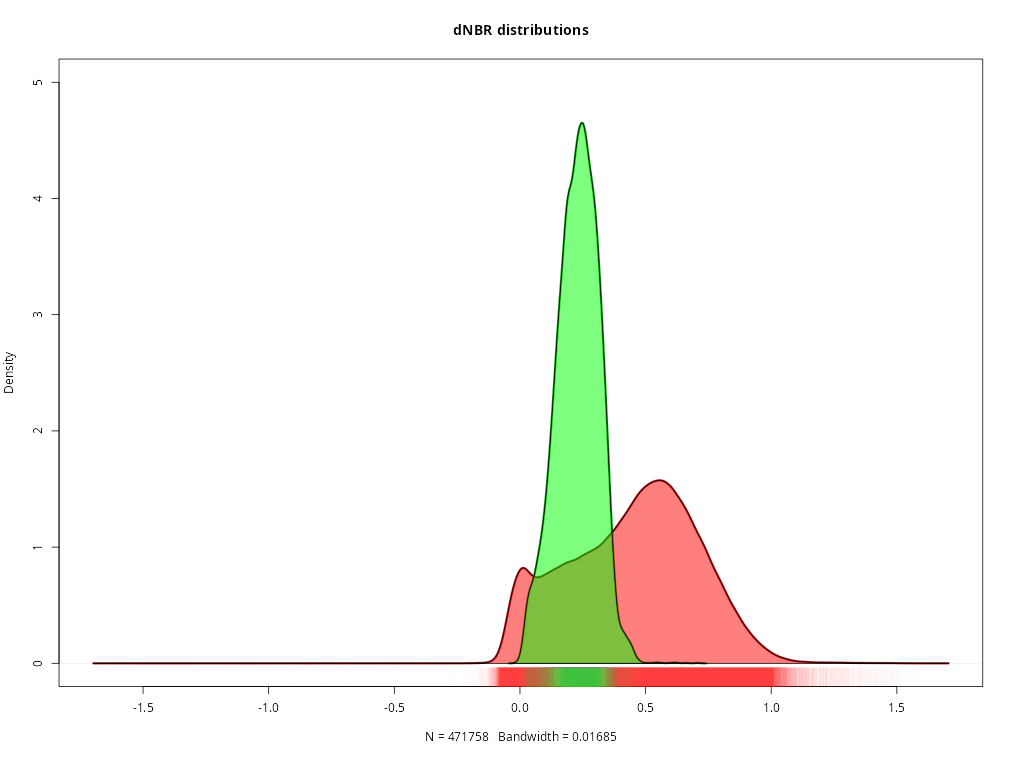

In [212]:
dnbr_rhodes <- read.csv("out/tables/dnbr_rhodes.csv")$x
dnbr_veluwe <- read.csv("out/tables/dnbr_veluwe.csv")$x

plot(density(dnbr_rhodes), main = "dNBR distributions",
     col = "firebrick", lwd = 3, ylim = c(0, 5))
lines(density(dnbr_veluwe), col = "forestgreen", lwd = 3)
polygon(density(dnbr_rhodes), col = rgb(1, 0, 0, alpha = 0.5))
polygon(density(dnbr_veluwe), col = rgb(0, 1, 0, alpha = 0.5))
rug(jitter(dnbr_rhodes), col = rgb(1, 0, 0, alpha = 0.05), lwd = 0.25)
rug(jitter(dnbr_veluwe), col = rgb(0, 1, 0, alpha = 0.05), lwd = 0.25)